# Task 3 — Experiment 3: historical + recent operating rates

This notebook keeps the sequential structure of
`03_modeling_stage1_with_history.py` and does not use
`modeling_experiments.py`.

Predict `ArrDel15` at scheduled departure using:

- schedule, calendar, weather, and scheduled-demand features;
- leakage-safe static historical carrier, airport, route, and schedule priors;
- leakage-safe recent operating-performance rates.

Train on 2024 and validate on 2025. Jan–May 2026 remains untouched.

Historical priors capture persistent structural risk. Recent-rate features
emulate a daily operational update and may use outcomes from sufficiently old
2025 dates, but never the flight's own date or the immediately preceding date.
This is therefore an online temporal backtest rather than a completely frozen
validation mapping.

In [1]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    log_loss,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from xgboost import DMatrix, XGBClassifier

repo_root = Path("..") if Path("../src").exists() else Path(".")
repo_root = repo_root.resolve()
os.chdir(repo_root)
sys.path.insert(0, str(repo_root / "src"))

from clean_data import load_split, select_arrival_target_rows
from features import (
    DEST_WEATHER_COLS,
    ORIGIN_WEATHER_COLS,
    add_destination_departure_keys,
    add_holiday_features,
    add_schedule_demand,
    add_weather_features,
    build_airport_timezone_lookup,
    load_airport_coordinates,
    scheduled_departure_timestamp,
)
from historical_features import (
    DEFAULT_HISTORICAL_RATE_SPECS,
    add_expanding_historical_rates,
    apply_historical_rate_state,
    fit_historical_rate_state,
    historical_feature_names,
)
from recent_performance_features import (
    DEFAULT_NATIONAL_WINDOWS,
    DEFAULT_RECENT_GROUP_SPECS,
    add_recent_rates_to_splits,
    recent_feature_names,
)

FIGURES = Path("figures")
MODELS = Path("models")
FIGURES.mkdir(exist_ok=True)
MODELS.mkdir(exist_ok=True)

RANDOM_STATE = 42
TRAIN_YEAR, VALID_YEAR = 2024, 2025
ROBUST_MODEL_NAME = "stage1_xgb_2024_to_2025_03"

# Set below 1 only for a quick pipeline smoke test. Final validation uses 1.0.
DEV_SAMPLE_FRAC = 1.0

AVAILABILITY_LAG_DAYS = 2
INITIAL_HISTORICAL_PRIOR = 0.20
INITIAL_RECENT_RATE_PRIOR = 0.20

## 1. Load the development years

Scheduled rows are loaded before model eligibility is applied because scheduled
demand must include flights that are later cancelled or diverted.

In [2]:
BTS_COLS = [
    "Year", "Month", "DayOfWeek", "DayofMonth", "FlightDate",
    "Reporting_Airline", "Origin", "Dest", "CRSDepTime",
    "CRSElapsedTime", "Distance", "ArrDel15", "Cancelled",
    "Diverted", "DivReachedDest", "DivArrDelay",
]

train_raw = load_split("train", columns=BTS_COLS, model_only=False)
valid_raw = load_split("val", columns=BTS_COLS, model_only=False)

if set(pd.to_numeric(train_raw["Year"], errors="raise").unique()) != {TRAIN_YEAR}:
    raise AssertionError("Unexpected training year")
if set(pd.to_numeric(valid_raw["Year"], errors="raise").unique()) != {VALID_YEAR}:
    raise AssertionError("Unexpected validation year")

print(f"2024 scheduled rows: {len(train_raw):,}")
print(f"2025 scheduled rows: {len(valid_raw):,}")

2024 scheduled rows: 7,079,061
2025 scheduled rows: 7,001,619


## 2. Build the leakage-safe feature tables

Base features are constructed independently by year. Static historical priors
are then added using past-only 2024 values for training and full-2024 mappings
for validation. Recent target-derived rates are calculated across the ordered
2024–2025 timeline using only outcomes old enough to have been available at
prediction time.

In [3]:
weather_path = Path("data/interim/weather_hourly.parquet")
wx = pd.read_parquet(weather_path)
wx["hour"] = pd.to_datetime(wx["hour"], errors="coerce")
if wx["hour"].isna().any():
    raise ValueError("weather_hourly.parquet contains invalid hours")
wx = wx[wx["hour"].dt.year.between(TRAIN_YEAR, VALID_YEAR)].copy()
if wx.duplicated(["airport", "hour"]).any():
    raise ValueError("Weather table has duplicate airport-hour rows")

weather_cols = list(dict.fromkeys([
    "airport", "hour", "observation_time_local", "weather_observation_missing",
    *ORIGIN_WEATHER_COLS, *DEST_WEATHER_COLS,
]))
wx = wx[[column for column in weather_cols if column in wx.columns]]

coords = load_airport_coordinates()
timezone_lookup = build_airport_timezone_lookup(coords)


def prepare_year(raw: pd.DataFrame) -> pd.DataFrame:
    """Build one leakage-safe Stage 1 model table."""
    n_raw = len(raw)
    keyed = add_destination_departure_keys(raw, timezone_lookup)
    model = select_arrival_target_rows(keyed)
    model["FlightDate"] = pd.to_datetime(model["FlightDate"]).dt.normalize()

    dep_ts = scheduled_departure_timestamp(model)
    model["sched_dep_hour"] = dep_ts.dt.hour.astype("int8")
    model["sched_dep_minute"] = dep_ts.dt.minute.astype("int8")
    model = add_holiday_features(model)
    model = add_schedule_demand(keyed, model)
    model = add_weather_features(
        model,
        wx,
        join_destination=True,
        dest_departure_hour_col="dest_departure_hour_local",
        dest_departure_time_col="dest_departure_time_local",
    )

    if len(model) > n_raw:
        raise AssertionError("Feature construction multiplied flight rows")
    for column in ("origin_weather_age_minutes", "dest_weather_age_minutes"):
        if column in model and model[column].dropna().lt(0).any():
            raise AssertionError(f"{column} contains future weather")
    return model.reset_index(drop=True)


train = prepare_year(train_raw)
valid = prepare_year(valid_raw)
del train_raw, valid_raw, wx

# Static target-derived history is supervised preprocessing. Training month m
# uses only months before m. Validation uses mappings fitted on all eligible 2024
# rows. Compute these features before any development sampling.
historical_state = fit_historical_rate_state(
    train,
    DEFAULT_HISTORICAL_RATE_SPECS,
)
train = add_expanding_historical_rates(
    train,
    DEFAULT_HISTORICAL_RATE_SPECS,
    initial_prior=INITIAL_HISTORICAL_PRIOR,
)
valid = apply_historical_rate_state(valid, historical_state)

# Recent target-derived rates are computed across the ordered train-validation
# timeline. A two-day availability lag means a flight on D can use outcomes only
# through D - 2. Compute these features before any development sampling.
train, valid = add_recent_rates_to_splits(
    train,
    valid,
    initial_prior=INITIAL_RECENT_RATE_PRIOR,
    availability_lag_days=AVAILABILITY_LAG_DAYS,
)

HISTORICAL_FEATURES = historical_feature_names(DEFAULT_HISTORICAL_RATE_SPECS)
RECENT_FEATURES = recent_feature_names()
for frame_name, frame in (("train", train), ("valid", valid)):
    if frame[HISTORICAL_FEATURES].isna().any().any():
        raise AssertionError(f"Missing historical-rate values in {frame_name}")
    if frame[RECENT_FEATURES].isna().any().any():
        raise AssertionError(f"Missing recent-rate values in {frame_name}")
    outside_range = (frame[RECENT_FEATURES] < 0) | (frame[RECENT_FEATURES] > 1)
    if outside_range.any().any():
        raise AssertionError(f"Recent-rate values outside [0, 1] in {frame_name}")

if DEV_SAMPLE_FRAC < 1:
    train = (
        train.groupby(["Month", "ArrDel15"], observed=True, group_keys=False)
        .sample(frac=DEV_SAMPLE_FRAC, random_state=RANDOM_STATE)
        .reset_index(drop=True)
    )
    valid = (
        valid.groupby(["Month", "ArrDel15"], observed=True, group_keys=False)
        .sample(frac=DEV_SAMPLE_FRAC, random_state=RANDOM_STATE)
        .reset_index(drop=True)
    )

print(f"Training rows  : {len(train):,} | delayed: {train['ArrDel15'].mean():.1%}")
print(f"Validation rows: {len(valid):,} | delayed: {valid['ArrDel15'].mean():.1%}")

print("\nValidation groups with no 2024 historical support:")
for name, _, _ in DEFAULT_HISTORICAL_RATE_SPECS:
    count_col = f"hist_{name}_log_count"
    rate_col = f"hist_{name}_delay_rate"
    if not valid[rate_col].between(0, 1).all():
        raise AssertionError(f"{rate_col} is outside [0, 1]")
    print(f"  {name:16s} {valid[count_col].eq(0).mean():.2%}")

recent_rate_audit = (
    valid.groupby("Month", observed=True)[["ArrDel15", *RECENT_FEATURES]]
    .mean()
    .rename(columns={"ArrDel15": "actual_delay_rate"})
)
print("\nValidation recent-rate audit")
print(recent_rate_audit.round(4).to_string())

  weather joined: 6,981,207 rows | origin weather missing 0.1%
  weather joined: 6,897,011 rows | origin weather missing 0.1%
Training rows  : 6,981,207 | delayed: 21.0%
Validation rows: 6,897,011 | delayed: 22.5%

Validation groups with no 2024 historical support:
  carrier          0.00%
  origin           0.04%
  dest             0.04%
  route            0.59%
  carrier_route    1.77%
  origin_hour      0.22%

Validation recent-rate audit
       actual_delay_rate  national_delay_rate_7d  national_delay_rate_28d  carrier_delay_rate_28d  origin_delay_rate_28d  dest_delay_rate_28d
Month                                                                                                                                        
1                 0.1893                  0.2144                   0.2262                  0.2261                 0.2264               0.2254
2                 0.2090                  0.2117                   0.1846                  0.1845                 0.1843        

## 3. Feature contract and category alignment

This candidate keeps the static historical priors from
`03_modeling_stage1_with_history.py` and adds five recent-rate features. The
comparison with the historical-only model measures the incremental value of
recent operating conditions.

In [4]:
SCHEDULE_FEATURES = [
    "Reporting_Airline", "Origin", "Dest", "Month", "DayOfWeek", "DayofMonth",
    "sched_dep_hour", "sched_dep_minute", "CRSElapsedTime", "Distance",
]
HOLIDAY_FEATURES = [
    "days_to_next_holiday", "days_since_prev_holiday",
    "next_holiday_name", "prev_holiday_name",
]
WEATHER_FEATURES = [
    *[f"origin_{column}" for column in ORIGIN_WEATHER_COLS],
    *[f"dest_{column}" for column in DEST_WEATHER_COLS],
    "origin_weather_age_minutes", "dest_weather_age_minutes",
    "origin_weather_observation_missing", "dest_weather_observation_missing",
]
DEMAND_FEATURES = [
    "origin_sched_deps_this_hour",
    "origin_sched_ops_this_hour",
    "dest_sched_arrivals_this_hour",
]
FEATURES = (
    SCHEDULE_FEATURES
    + HOLIDAY_FEATURES
    + WEATHER_FEATURES
    + DEMAND_FEATURES
    + HISTORICAL_FEATURES
    + RECENT_FEATURES
)
CATEGORICAL = [
    "Reporting_Airline", "Origin", "Dest", "Month", "DayOfWeek",
    "next_holiday_name", "prev_holiday_name",
    "origin_flight_category", "dest_flight_category",
]

missing_train = sorted(set(FEATURES) - set(train.columns))
missing_valid = sorted(set(FEATURES) - set(valid.columns))
if missing_train or missing_valid:
    raise KeyError(
        f"Missing model features; train={missing_train}, valid={missing_valid}"
    )

LEAKAGE_FIELDS = {
    "DepTime", "DepDelay", "DepDel15", "TaxiOut", "WheelsOff", "WheelsOn",
    "ArrTime", "ArrDelay", "ArrDelayMinutes", "ActualElapsedTime", "Cancelled",
    "Diverted", "CarrierDelay", "WeatherDelay", "NASDelay", "SecurityDelay",
    "LateAircraftDelay",
}
overlap = LEAKAGE_FIELDS.intersection(FEATURES)
if overlap:
    raise AssertionError(f"Post-cutoff fields entered the feature list: {sorted(overlap)}")


def align_categories(
    train_x: pd.DataFrame,
    valid_x: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame, dict[str, int], dict[str, list[str]]]:
    """Learn category levels from 2024 and map unseen 2025 values explicitly."""
    train_x = train_x.copy()
    valid_x = valid_x.copy()
    unseen_counts: dict[str, int] = {}
    category_levels: dict[str, list[str]] = {}

    for column in CATEGORICAL:
        train_values = train_x[column].astype("string").fillna("__MISSING__")
        valid_values = valid_x[column].astype("string").fillna("__MISSING__")
        known = set(train_values.unique())
        valid_values = valid_values.where(valid_values.isin(known), "__UNSEEN__")
        levels = sorted(known | {"__UNSEEN__"})

        train_x[column] = pd.Categorical(train_values, categories=levels)
        valid_x[column] = pd.Categorical(valid_values, categories=levels)
        unseen_counts[column] = int(valid_values.eq("__UNSEEN__").sum())
        category_levels[column] = levels

    numeric = [column for column in FEATURES if column not in CATEGORICAL]
    for frame in (train_x, valid_x):
        frame[numeric] = (
            frame[numeric]
            .apply(pd.to_numeric, errors="coerce")
            .astype("float32")
        )
        if np.isinf(frame[numeric].to_numpy()).any():
            raise ValueError("Infinite numeric feature values found")

    return train_x, valid_x, unseen_counts, category_levels


X_train, X_valid, unseen_counts, category_levels = align_categories(
    train[FEATURES],
    valid[FEATURES],
)
y_train = train["ArrDel15"].astype("int8").reset_index(drop=True)
y_valid = valid["ArrDel15"].astype("int8").reset_index(drop=True)
valid_meta = valid[
    ["FlightDate", "Month", "Reporting_Airline", "Origin", "Dest"]
].reset_index(drop=True).copy()
del train, valid

print(f"Features: {len(FEATURES)} ({len(CATEGORICAL)} categorical)")
print("Unseen validation categories:")
for column, count in unseen_counts.items():
    print(f"  {column:35s} {count:>8,}")

Features: 54 (9 categorical)
Unseen validation categories:
  Reporting_Airline                          0
  Origin                                 2,486
  Dest                                   2,490
  Month                                      0
  DayOfWeek                                  0
  next_holiday_name                          0
  prev_holiday_name                          0
  origin_flight_category                     0
  dest_flight_category                       0


## 4. Fit Experiment 3

The model and hyperparameters match the historical-only experiment so the
comparison isolates the incremental value of recent operating rates.

In [5]:
model = XGBClassifier(
    objective="binary:logistic",
    n_estimators=3_000,
    learning_rate=0.05,
    max_depth=8,
    min_child_weight=20,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.05,
    reg_lambda=5.0,
    max_bin=256,
    tree_method="hist",
    enable_categorical=True,
    max_cat_to_onehot=16,
    eval_metric=["logloss", "aucpr"],
    early_stopping_rounds=100,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=50)
p_valid = model.predict_proba(X_valid)[:, 1]
print(f"Best iteration: {model.best_iteration}")

[0]	validation_0-logloss:0.53022	validation_0-aucpr:0.36839
[50]	validation_0-logloss:0.49110	validation_0-aucpr:0.40618
[100]	validation_0-logloss:0.48752	validation_0-aucpr:0.41579
[150]	validation_0-logloss:0.48679	validation_0-aucpr:0.41757
[200]	validation_0-logloss:0.48644	validation_0-aucpr:0.41893
[250]	validation_0-logloss:0.48622	validation_0-aucpr:0.41991
[300]	validation_0-logloss:0.48635	validation_0-aucpr:0.41976
[347]	validation_0-logloss:0.48653	validation_0-aucpr:0.41937
Best iteration: 247


## 5. Validation metrics and baselines

The constant baseline predicts the 2024 training prevalence for every 2025
flight. The model should improve PR-AUC and reduce both log loss and Brier score.

In [6]:
def expected_calibration_error(
    y: pd.Series | np.ndarray,
    probabilities: np.ndarray,
    bins: int = 10,
) -> float:
    table = pd.DataFrame(
        {"y": np.asarray(y), "p": np.asarray(probabilities)}
    )
    table["bin"] = pd.qcut(table["p"], q=bins, duplicates="drop")
    grouped = table.groupby("bin", observed=True).agg(n=("y", "size"), actual=("y", "mean"), predicted=("p", "mean"))
    return np.average((grouped["actual"] - grouped["predicted"]).abs(), weights=grouped["n"])


def capture_at_fraction(
    y: pd.Series | np.ndarray,
    probabilities: np.ndarray,
    fraction: float = 0.10,
) -> float:
    n = max(1, int(np.ceil(len(y) * fraction)))
    idx = np.argpartition(np.asarray(probabilities), -n)[-n:]
    positives = np.asarray(y).sum()
    return np.asarray(y)[idx].sum() / positives if positives else np.nan


def metric_row(
    name: str,
    y: pd.Series | np.ndarray,
    probabilities: np.ndarray,
    *,
    ece_override: float | None = None,
) -> dict[str, str | float]:
    return {
        "model": name,
        "PR_AUC": average_precision_score(y, probabilities),
        "ROC_AUC": roc_auc_score(y, probabilities),
        "log_loss": log_loss(y, probabilities, labels=[0, 1]),
        "Brier": brier_score_loss(y, probabilities),
        "ECE_10":  expected_calibration_error(y, probabilities) if ece_override is None
            else ece_override,
        "delay_capture_top10pct": capture_at_fraction(y, probabilities, 0.10),
    }


train_prevalence = float(y_train.mean())
valid_prevalence = float(y_valid.mean())
p_baseline = np.full(len(y_valid), train_prevalence, dtype="float32")
metrics = pd.DataFrame([
    metric_row("2025 prevalence baseline", y_valid, p_baseline, ece_override=abs(valid_prevalence - train_prevalence)),
    metric_row("Stage 1 XGBoost", y_valid, p_valid),
]).set_index("model")
print(metrics.round(4).to_string())
print(f"\n2025 positive-class prevalence / no-skill PR-AUC: {y_valid.mean():.4f}")

                          PR_AUC  ROC_AUC  log_loss   Brier  ECE_10  delay_capture_top10pct
model                                                                                      
2025 prevalence baseline  0.2250   0.5000    0.5339  0.1746  0.0151                  0.0994
Stage 1 XGBoost           0.4197   0.7015    0.4863  0.1576  0.0120                  0.2234

2025 positive-class prevalence / no-skill PR-AUC: 0.2250


 - Adding recent rolling delay rates preserved most of the ranking performance
   of the historical-feature model, although PR-AUC decreased slightly from
   **0.4235 to 0.4197** and top-10% capture from **22.44% to 22.34%**.
 - Probability accuracy improved: log loss decreased to **0.4863** and Brier
   score to **0.1576**, both the best results so far.
 - ECE-10 improved substantially from **0.0259 to 0.0120**, indicating much
   better aggregate probability calibration.
 - ROC-AUC remained essentially unchanged at **0.7015**.
 - Recent-performance features appear to improve probability calibration more than
   ranking. 

## 6. Ranking and calibration plots

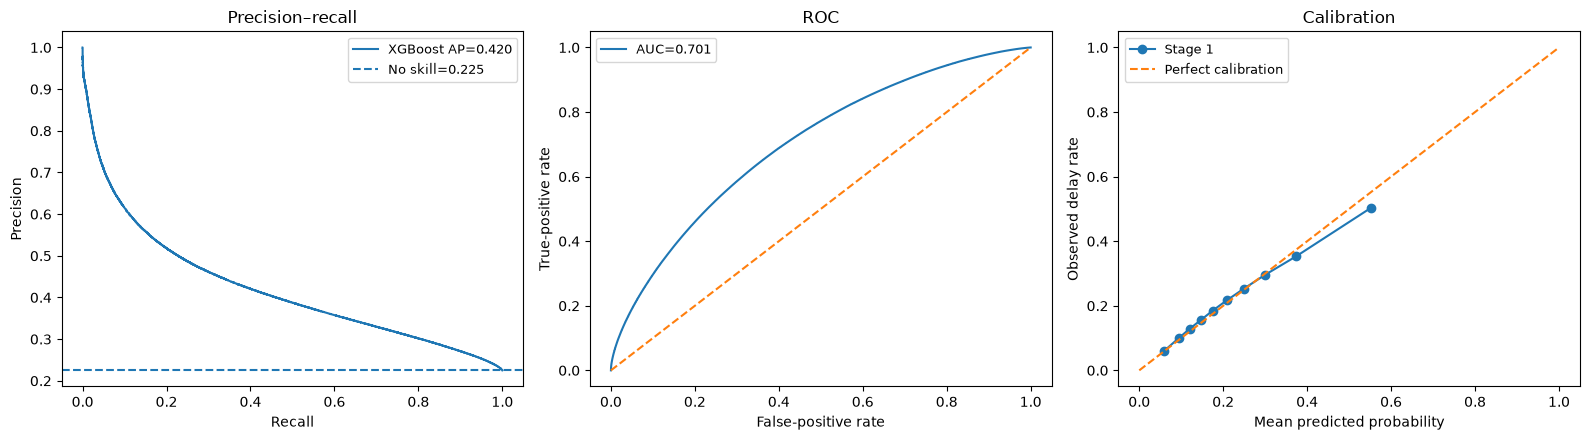

In [7]:
precision, recall, _ = precision_recall_curve(y_valid, p_valid)
fpr, tpr, _ = roc_curve(y_valid, p_valid)
frac_pos, mean_pred = calibration_curve(y_valid, p_valid, n_bins=10, strategy="quantile")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].plot(recall, precision, label=f"XGBoost AP={metrics.loc['Stage 1 XGBoost', 'PR_AUC']:.3f}")
axes[0].axhline(y_valid.mean(), linestyle="--", label=f"No skill={y_valid.mean():.3f}")
axes[0].set(xlabel="Recall", ylabel="Precision", title="Precision–recall")
axes[0].legend(fontsize=9)

axes[1].plot(fpr, tpr, label=f"AUC={metrics.loc['Stage 1 XGBoost', 'ROC_AUC']:.3f}")
axes[1].plot([0, 1], [0, 1], linestyle="--")
axes[1].set(xlabel="False-positive rate", ylabel="True-positive rate", title="ROC")
axes[1].legend(fontsize=9)

axes[2].plot(mean_pred, frac_pos, marker="o", label="Stage 1")
axes[2].plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
axes[2].set(xlabel="Mean predicted probability", ylabel="Observed delay rate", title="Calibration")
axes[2].legend(fontsize=9)

plt.tight_layout()
fig.savefig(FIGURES / "03_stage1_03_validation_curves.png", bbox_inches="tight")
plt.show()

- Calibration improved substantially. Most probability bins below about 30%
  predicted risk lie close to the perfect-calibration line, consistent with
  the lower **ECE-10 of 0.012**.
- The highest-risk bins fall modestly below the diagonal, indicating some
  overprediction among flights assigned the largest delay probabilities.

## 7. Diagnostic operating threshold

The hurdle model uses probabilities directly and does not require a threshold.
For a confusion matrix only, report the 2025 threshold that maximizes F1. This
is a development choice and must be frozen before final 2026 scoring.

In [8]:
pr_precision, pr_recall, thresholds = precision_recall_curve(y_valid, p_valid)
f1 = 2 * pr_precision[:-1] * pr_recall[:-1] / np.maximum(pr_precision[:-1] + pr_recall[:-1], 1e-12)
best_idx = int(np.nanargmax(f1))
best_threshold = float(thresholds[best_idx])


def threshold_metrics(threshold: float) -> dict[str, float | int]:
    pred = p_valid >= threshold
    tn, fp, fn, tp = confusion_matrix(y_valid, pred).ravel()
    return {
        "threshold": threshold,
        "precision": precision_score(y_valid, pred, zero_division=0),
        "recall": recall_score(y_valid, pred, zero_division=0),
        "specificity": tn / (tn + fp),
        "predicted_positive_rate": pred.mean(),
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
    }


threshold_table = pd.DataFrame([
    threshold_metrics(t) for t in sorted(set([0.10, 0.20, 0.30, 0.40, 0.50, best_threshold]))
])
print(f"Diagnostic max-F1 threshold: {best_threshold:.3f}")
print(threshold_table.round(3).to_string(index=False))

Diagnostic max-F1 threshold: 0.215
 threshold  precision  recall  specificity  predicted_positive_rate      TP      FP      FN      TN
     0.100      0.256   0.942        0.207                    0.827 1461786 4238875   90367 1105983
     0.200      0.331   0.697        0.591                    0.474 1081272 2186964  470881 3157894
     0.215      0.342   0.655        0.634                    0.431 1017260 1954971  534893 3389887
     0.300      0.405   0.446        0.810                    0.248  691909 1016431  860244 4328427
     0.400      0.481   0.260        0.918                    0.122  404200  436408 1147953 4908450
     0.500      0.563   0.145        0.967                    0.058  225041  174636 1327112 5170222


Experiment 1
- precision = 34.2%
- recall = 64.6%
- specificity = 63.9%
- predicted-positive rate = 42.5%

Experiment 2
- precision = 34.2%
- recall = 65.6%
- specificity = 63.4%
- predicted-positive rate = 43.1%

Very similar to Experiment 2

## 8. Temporal stability within 2025

A useful Stage 1 model should beat the monthly prevalence baseline throughout
the year, not only in aggregate. Large changes in PR-AUC, Brier score or mean
prediction indicate drift or poor calibration in specific months.

 period  flights  actual_rate  mean_prediction  PR_AUC  ROC_AUC  Brier
2025-01   523167       0.1893           0.2394  0.3829   0.6891 0.1432
2025-02   497343       0.2090           0.2216  0.4196   0.6971 0.1489
2025-03   593741       0.1978           0.2282  0.3676   0.6894 0.1476
2025-04   578961       0.1983           0.2000  0.3877   0.6960 0.1445
2025-05   599192       0.2381           0.2534  0.4359   0.6974 0.1642
2025-06   601662       0.2852           0.2462  0.5115   0.7192 0.1798
2025-07   615731       0.2922           0.3348  0.4818   0.6970 0.1904
2025-08   595815       0.2283           0.2208  0.4253   0.7034 0.1588
2025-09   559481       0.1680           0.1512  0.3241   0.6918 0.1300
2025-10   602559       0.2045           0.1651  0.3824   0.6945 0.1507
2025-11   556244       0.2070           0.1952  0.3906   0.6948 0.1497
2025-12   573115       0.2692           0.2671  0.4671   0.6903 0.1775


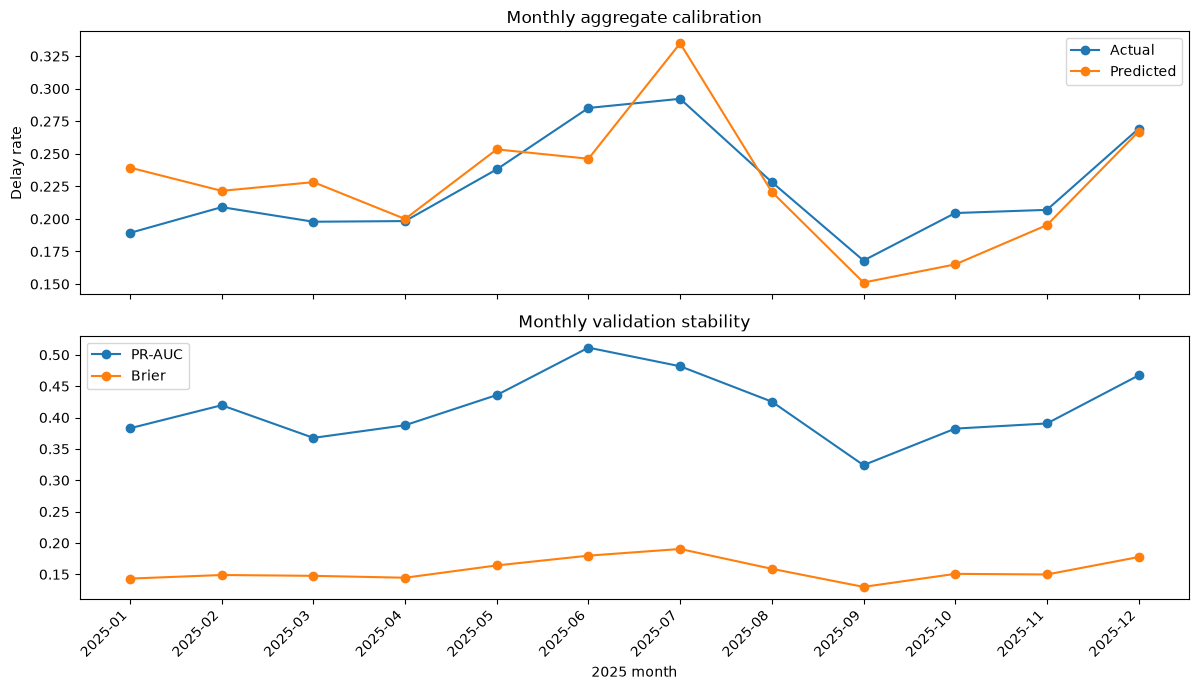

In [9]:
validation_results = valid_meta.reset_index(drop=True).assign(
    y_true=np.asarray(y_valid),
    p_delay=p_valid,
)
validation_results["period"] = pd.to_datetime(validation_results["FlightDate"]).dt.to_period("M").astype(str)

monthly = []
for period, group in validation_results.groupby("period", observed=True):
    monthly.append({
        "period": period,
        "flights": len(group),
        "actual_rate": group["y_true"].mean(),
        "mean_prediction": group["p_delay"].mean(),
        "PR_AUC": average_precision_score(group["y_true"], group["p_delay"]),
        "ROC_AUC": roc_auc_score(group["y_true"], group["p_delay"]),
        "Brier": brier_score_loss(group["y_true"], group["p_delay"]),
    })
monthly = pd.DataFrame(monthly)
print(monthly.round(4).to_string(index=False))

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(monthly["period"], monthly["actual_rate"], marker="o", label="Actual")
axes[0].plot(monthly["period"], monthly["mean_prediction"], marker="o", label="Predicted")
axes[0].set(ylabel="Delay rate", title="Monthly aggregate calibration")
axes[0].legend()
axes[1].plot(monthly["period"], monthly["PR_AUC"], marker="o", label="PR-AUC")
axes[1].plot(monthly["period"], monthly["Brier"], marker="o", label="Brier")
axes[1].set(xlabel="2025 month", title="Monthly validation stability")
axes[1].legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
fig.savefig(FIGURES / "03_stage1_03_monthly_validation.png", bbox_inches="tight")
plt.show()

 - Adding leakage-safe recent-performance rates substantially reduced the
   late-2025 calibration drift seen in the historical-only model.
 - October remains underpredicted, but the gap is smaller; November is close,
   and December's predicted and observed delay rates are nearly identical.
 - This supports the interpretation that recent delay rates help the model adapt
   to changes in the overall operating environment.
 - Some overreaction is visible. July is substantially overpredicted following
   the high-delay conditions observed in June, which is plausible for rolling
   recent-performance features.
 - Ranking performance remains positive across all months, although September
   is the weakest period.

 period  actual_rate  mean_prediction  calibration_gap  pr_auc_lift  brier_skill
2025-01       0.1893           0.2394           0.0501       2.0230       0.0671
2025-02       0.2090           0.2216           0.0125       2.0073       0.0995
2025-03       0.1978           0.2282           0.0304       1.8579       0.0701
2025-04       0.1983           0.2000           0.0016       1.9549       0.0909
2025-05       0.2381           0.2534           0.0153       1.8309       0.0949
2025-06       0.2852           0.2462          -0.0390       1.7934       0.1182
2025-07       0.2922           0.3348           0.0426       1.6487       0.0794
2025-08       0.2283           0.2208          -0.0075       1.8634       0.0987
2025-09       0.1680           0.1512          -0.0169       1.9287       0.0704
2025-10       0.2045           0.1651          -0.0394       1.8695       0.0736
2025-11       0.2070           0.1952          -0.0117       1.8871       0.0877
2025-12       0.2692        

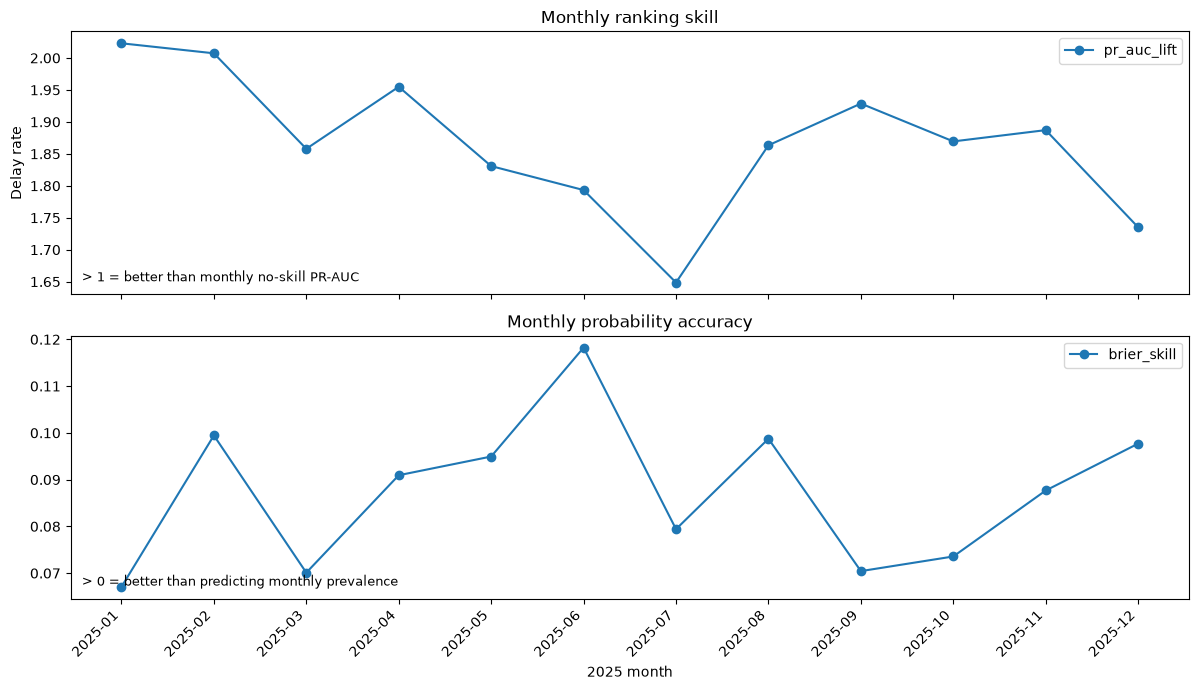

In [10]:
# Raw monthly PR-AUC partly changes with monthly delay prevalence. Check PR_AUC / prevalence.
# Brier score also depends on prevalence. A lower Brier score in a low-delay month does not 
# automatically mean better model performance. Evaluate with a month-specific prevalence baseline.

monthly["calibration_gap"] = (
    monthly["mean_prediction"] - monthly["actual_rate"]
)
monthly["pr_auc_lift"] = (
    monthly["PR_AUC"] / monthly["actual_rate"]
)
monthly["baseline_brier"] = (
    monthly["actual_rate"] * (1 - monthly["actual_rate"])
)
monthly["brier_skill"] = (
    1 - monthly["Brier"] / monthly["baseline_brier"]
)
print(
    monthly[
        [
            "period",
            "actual_rate",
            "mean_prediction",
            "calibration_gap",
            "pr_auc_lift",
            "brier_skill",
        ]
    ].round(4).to_string(index=False)
)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(monthly["period"], monthly["pr_auc_lift"], marker="o", label="pr_auc_lift")
axes[0].set(ylabel="Delay rate", title="Monthly ranking skill")
axes[0].text(
    0.01, 0.05,
    "> 1 = better than monthly no-skill PR-AUC",
    transform=axes[0].transAxes,
    fontsize=9,
)
axes[0].legend()
axes[1].plot(monthly["period"], monthly["brier_skill"], marker="o", label="brier_skill")
axes[1].set(xlabel="2025 month", title="Monthly probability accuracy")
axes[1].text(
    0.01, 0.05,
    "> 0 = better than predicting monthly prevalence",
    transform=axes[1].transAxes,
    fontsize=9,
)
axes[1].legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
fig.savefig(FIGURES / "03_stage1_02_monthly_skill.png", bbox_inches="tight")
plt.show()

## 9. Gain importance and saved development artifacts

Gain importance is a model-debugging view, not the final interpretation. SHAP
and permutation importance are run after the Stage 1 specification is accepted.

In [11]:
importance = (
    pd.Series(
        model.get_booster().get_score(importance_type="gain"),
        name="gain",
    )
    .rename_axis("feature")
    .reset_index()
    .sort_values("gain", ascending=False)
    .reset_index(drop=True)
)
importance["gain_share"] = importance["gain"] / importance["gain"].sum()
importance["cumulative_gain_share"] = importance["gain_share"].cumsum()

print(
    importance[
        ["feature", "gain", "gain_share", "cumulative_gain_share"]
    ].head(20).to_string(
        index=False,
        formatters={
            "gain": "{:,.1f}".format,
            "gain_share": "{:.1%}".format,
            "cumulative_gain_share": "{:.1%}".format,
        },
    )
)

                      feature    gain gain_share cumulative_gain_share
         origin_frozen_precip 1,423.6      15.6%                 15.6%
          origin_thunderstorm   987.9      10.8%                 26.4%
               sched_dep_hour   699.5       7.7%                 34.1%
             origin_precip_3h   592.0       6.5%                 40.6%
            dest_thunderstorm   536.3       5.9%                 46.5%
       carrier_delay_rate_28d   335.6       3.7%                 50.1%
hist_carrier_route_delay_rate   302.9       3.3%                 53.4%
       origin_ifr_hours_past3   279.6       3.1%                 56.5%
         dest_flight_category   278.6       3.1%                 59.6%
            next_holiday_name   240.6       2.6%                 62.2%
           dest_frozen_precip   226.7       2.5%                 64.7%
  hist_origin_hour_delay_rate   220.7       2.4%                 67.1%
       national_delay_rate_7d   215.1       2.4%                 69.5%
      

### 9.1 TreeSHAP global importance

Identify which features make the largest contributions to its 2025 validation predictions. Sampling keeps the computation practical without changing the fitted model.

In [12]:
SHAP_SAMPLE_N = 50_000
shap_sample = X_valid.sample(
    n=min(SHAP_SAMPLE_N, len(X_valid)),
    random_state=RANDOM_STATE,
).copy()

shap_dmatrix = DMatrix(shap_sample, enable_categorical=True)
shap_contrib = model.get_booster().predict(
    shap_dmatrix,
    pred_contribs=True,
    approx_contribs=False,
    validate_features=True,
)

if shap_contrib.shape[1] != len(FEATURES) + 1:
    raise AssertionError(
        "TreeSHAP output should contain one contribution per feature plus the bias term"
    )

shap_values = shap_contrib[:, :-1]
shap_base_values = shap_contrib[:, -1]

# TreeSHAP contributions should reconstruct the raw XGBoost margin.
raw_margin = model.get_booster().predict(
    shap_dmatrix,
    output_margin=True,
    validate_features=True,
)
max_additivity_error = float(
    np.max(np.abs(raw_margin - (shap_base_values + shap_values.sum(axis=1))))
)
print(f"SHAP sample rows: {len(shap_sample):,}")
print(f"Max TreeSHAP additivity error: {max_additivity_error:.3e}")

shap_importance = pd.DataFrame({
    "feature": FEATURES,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
})
shap_importance = shap_importance.sort_values(
    "mean_abs_shap", ascending=False
).reset_index(drop=True)
shap_importance["shap_share"] = (
    shap_importance["mean_abs_shap"] / shap_importance["mean_abs_shap"].sum()
)
shap_importance["cumulative_shap_share"] = shap_importance["shap_share"].cumsum()

print("\nTop TreeSHAP model drivers")
print(
    shap_importance.head(20).to_string(
        index=False,
        formatters={
            "mean_abs_shap": "{:.4f}".format,
            "shap_share": "{:.1%}".format,
            "cumulative_shap_share": "{:.1%}".format,
        },
    )
)

SHAP sample rows: 50,000
Max TreeSHAP additivity error: 4.292e-06

Top TreeSHAP model drivers
                      feature mean_abs_shap shap_share cumulative_shap_share
               sched_dep_hour        0.3482      16.7%                 16.7%
       national_delay_rate_7d        0.1283       6.2%                 22.9%
hist_carrier_route_delay_rate        0.1087       5.2%                 28.1%
  hist_origin_hour_delay_rate        0.1037       5.0%                 33.0%
                       Origin        0.1029       4.9%                 38.0%
                         Dest        0.1026       4.9%                 42.9%
       carrier_delay_rate_28d        0.0924       4.4%                 47.3%
                    DayOfWeek        0.0790       3.8%                 51.1%
         dest_flight_category        0.0788       3.8%                 54.9%
         days_to_next_holiday        0.0711       3.4%                 58.3%
             origin_precip_3h        0.0640       3.1%     

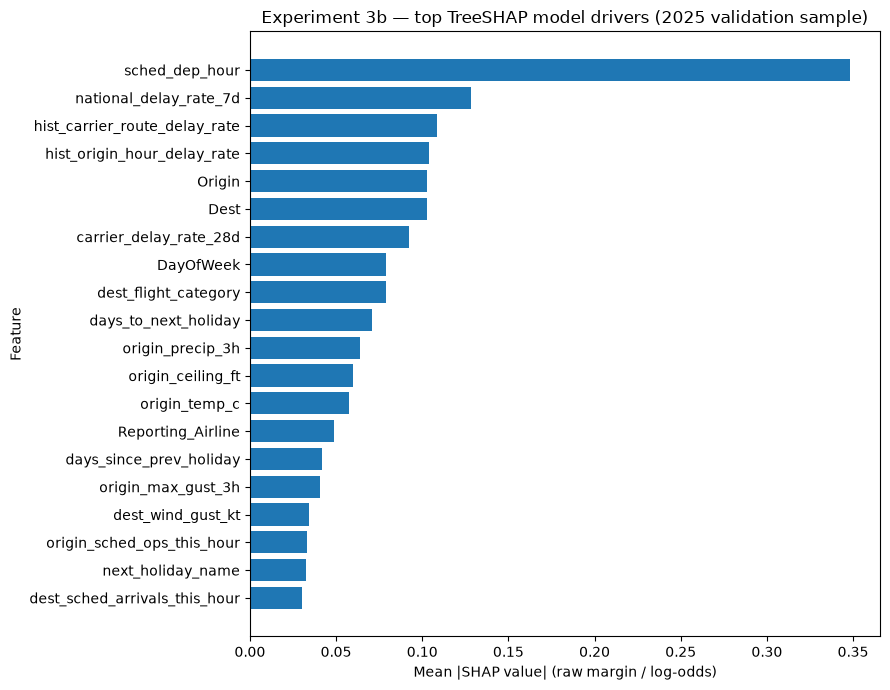

In [13]:
plot_shap = shap_importance.head(20).sort_values("mean_abs_shap")
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(plot_shap["feature"], plot_shap["mean_abs_shap"])
ax.set(
    xlabel="Mean |SHAP value| (raw margin / log-odds)",
    ylabel="Feature",
    title="Experiment 3b — top TreeSHAP model drivers (2025 validation sample)",
)
plt.tight_layout()
fig.savefig(FIGURES / "03_stage1_03b_shap_importance.png", bbox_inches="tight")
plt.show()

## 10. Save comparable experiment artifacts

These files can be concatenated with other experiment outputs for cross-experiment evaluation later.

In [14]:
model_path = MODELS / f"{ROBUST_MODEL_NAME}.json"
metadata_path = MODELS / f"{ROBUST_MODEL_NAME}_metadata.json"
history_path = MODELS / f"{ROBUST_MODEL_NAME}_historical_state.joblib"
model.save_model(model_path)
joblib.dump(historical_state, history_path)
metadata = {
    "train_year": TRAIN_YEAR,
    "validation_year": VALID_YEAR,
    "features": FEATURES,
    "categorical_features": CATEGORICAL,
    "historical_feature_specs": [
        {"name": name, "columns": list(columns), "smoothing": smoothing}
        for name, columns, smoothing in DEFAULT_HISTORICAL_RATE_SPECS
    ],
    "historical_global_rate": float(historical_state["global_rate"]),
    "best_iteration": int(model.best_iteration),
    "diagnostic_f1_threshold": best_threshold,
    "validation_metrics": metrics.loc["Stage 1 XGBoost"].to_dict(),
}
metadata_path.write_text(json.dumps(metadata, indent=2))
print(f"Saved model      : {model_path}")
print(f"Saved history    : {history_path}")
print(f"Saved metadata   : {metadata_path}")

Saved model      : models/stage1_xgb_2024_to_2025_03.json
Saved history    : models/stage1_xgb_2024_to_2025_03_historical_state.joblib
Saved metadata   : models/stage1_xgb_2024_to_2025_03_metadata.json


## Improvements

Keep the historical features because they improve discrimination. To address
temporal drift, tryleakage-safe recent network and group delay-rate features
based only on outcomes available before each flight.